<a href="https://colab.research.google.com/github/poojithavakada7-hue/Spam_or_Notspam/blob/main/Spam_Or_NotSpam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

In [ ]:
df = pd.read_csv("spam.csv", encoding='latin1')

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Information:")
print(df.info())

First 5 rows of dataset:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed

In [ ]:
print("\n Missing values")
print(df.isnull().sum())
print(df.shape)


 Missing values
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64
(5572, 5)


In [ ]:
df = df[['v1', 'v2']]
df.columns = ['Labels', 'message']
df.head()

,Labels,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Labels'].map({'ham':0,'spam':1})

,Labels
0,0
1,0
2,1
3,0
4,0
...,...
5567,1
5568,0
5569,0
5570,0


In [ ]:
import nltk
import string

from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words=stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def cleantext(text):
  text=text.lower()
  text=text.translate(str.maketrans('','',string.punctuation))
  words=text.split()
  words=[word for word in words if word not in stop_words]
  return ' '.join(words)
df['message']=df['message'].apply(cleantext)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df['message'])
y = df['Labels']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
nb = MultinomialNB()
nb.fit(x_train,y_train)
pred_nb = nb.predict(x_test)
print("Naive Bayes Accuracy:",accuracy_score(y_test,pred_nb))

Naive Bayes Accuracy: 0.9659192825112107


In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
pred_lr = lr.predict(x_test)
print("Logistic Regression Accuracy:",accuracy_score(y_test,pred_lr))

Logistic Regression Accuracy: 0.9426008968609866


In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train,y_train)
pred_svm = svm.predict(x_test)
print("Support vector machine Accuracy:",accuracy_score(y_test,pred_svm))

Support vector machine Accuracy: 0.967713004484305


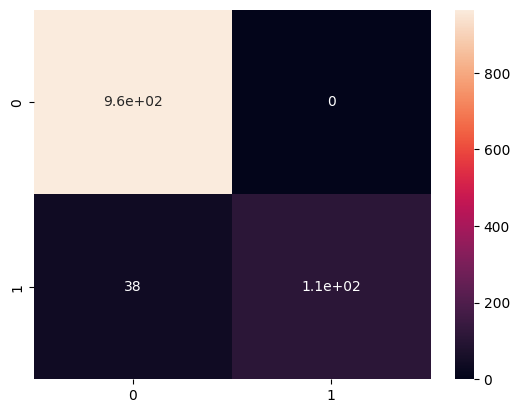

In [ ]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,pred_nb),annot=True)
plt.show()

In [ ]:
def predict_spam(text):
    text = cleantext(text)
    text = vectorizer.transform([text])
    result = nb.predict(text)
    if result[0]=='spam':
        print("Spam Message")
    else:
        print("Ham Message")
predict_spam("WINNER!! As a valued network customer you have been selected to receivea �900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.")
predict_spam("Fine if that��s the way u feel. That��s the way its gota b")

Spam Message
Ham Message
